# [The StatQuest Illustrated Guide to Statistics](https://www.amazon.com/dp/B0GMP7Z9ZL)
## Chapter 05 - Quantifying Confidence in our Decisions with *p*-values!!!

Copyright 2026, Joshua Starmer

In this notebook we’ll learn how to...

- Calculate probabitlies with the **Binomal Distribution**.
- Calculate *p*-values with the **Binomial Distribution**.
- Observe an increase in False Positives when we use **One-Sided *p*-values**.

**NOTE:**
This tutorial assumes that you have installed **[Python](https://www.python.org/)** and read Chapter 5 in **[The StatQuest Illustrated Guide to Statistics](https://www.amazon.com/dp/B0GMP7Z9ZL)**.

----

Since we're using Python, the first thing we do is load in some modules that will help us do math and plot graphs.

In [1]:
import numpy as np # to generate random of numbers
import seaborn as sns # to draw a graphs and have them look somewhat nice
from scipy.stats import binom, binomtest

# Calculate probabilities with the **Binomial Distribution**

We'll start by calculating probabilities for coin tosses with the `binom.pmf()` function. Here `pmf`  stands for **Probability Mass Function** because discrete statistical distributions are also called **Mass Functions**. 

Anyway, `binom.pmf()` requires 3 parameters, `k`, the number of successes, `n`, the number of trials and `p`, the probability of getting a success. In our example, `k` is the number of times we get heads, `n` is the number of times we flip the coin and `p` is the probability that the coin will land on Heads, which, in our example, is 0.5.

So, to calculate the probability that we get 2 heads in 2 tosses, we use the follow function call:

In [2]:
binom.pmf(k=2, n=2, p=0.5)

np.float64(0.25)

To calculate the probability of getting 1 heads in 2 tosses, we use the following function call:

In [3]:
binom.pmf(k=1, n=2, p=0.5)

np.float64(0.5000000000000002)

And to calculate the probability of getting 0 heads in 2 tosses, and getting 2 tails instead, we use the following function call:

In [4]:
binom.pmf(k=0, n=2, p=0.5)

np.float64(0.25)

**NOTE:** If we wanted to draw a histogram style graph that shows bars that reflect these probabilities, we can calculate all 3 probabilities at once by passing in the 3 ways we can get heads like this..

In [5]:
# create a list that has all of the outcomes we want to calculate probabilities for
x_vals = [2, 1, 0]

# calculate the probabilities for all of the values in x_vals
prob_vals = binom.pmf(k=x_vals, n=2, p=0.5)

# print out the probabilities
prob_vals

array([0.25, 0.5 , 0.25])

Now we can use `x_vals` and `prob_vals` to draw the histogram like graph with the `sns.barplot()` function. The `sns.barplot()` can take a lot of arguments, but, for our example, we only need to specify the the bins with `x=x_vals` and the height of each bar with `y=prob_vals`. We'll also give the x-axis an overall label `set(xlabel='Number of Heads')`.

[Text(0.5, 0, 'Number of Heads')]

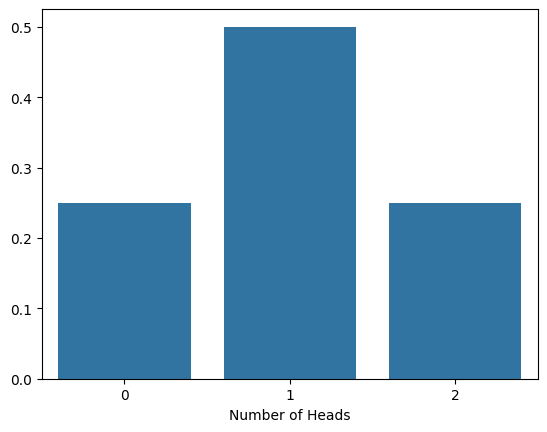

In [6]:
## draw the histogram...
my_bar = sns.barplot(x=x_vals, y=prob_vals)
## add an overall label to the x-axis
my_bar.set(xlabel='Number of Heads')

# Bam!

Now that we know how to calculate probabilities with the **Binomial Distribution** and draw a histogram like plot with those probabilities, let's learn how to calculate *p*-values with the **Binomial Distribution**.

----

To calculate *p*-values with the **Binomial Distribution** we can use the `binomtest()` function. In order to use `binom.test()`, we set `k`, the number of successes, `n`, the number of trials, and `p`, the probability of a success. In our example, `k` is the number of times we get Heads, `n` is the number of times we flip the coin, and `p` is the probability that the coin lands on heads.

So, if we wanted to calculate the *p*-value for getting 2 heads in 2 flips, we would use the following call to `binomtest()`.

In [7]:
binomtest(k=2, n=2, p=0.5)

BinomTestResult(k=2, n=2, alternative='two-sided', statistic=1.0, pvalue=0.5)

In the output, on the right side, we can see the *p*-value, 0.5, which is what we calculated in the book.

Now let's calculate the *p*-value for getting 4 heads in 5 coin tosses...

In [8]:
binomtest(k=4, n=5, p=0.5)

BinomTestResult(k=4, n=5, alternative='two-sided', statistic=0.8, pvalue=0.375)

...and we get the same *p*-value, 0.375, that we got in the book (with rounding).

Lastly, let's calculate the *p*-value for getting 1 head in 10 coin tosses...

In [9]:
binomtest(k=1, n=10, p=0.5)

BinomTestResult(k=1, n=10, alternative='two-sided', statistic=0.1, pvalue=0.021484375)

...and we get the same *p*-value, 0.02, that we got in the book (with rounding).

## Double BAM!!

Now let's observe an increase in False Positives when we use One-Sided *p*-values.

----

# Observe an increase in False Positives when we use **One-Sided *p*-values**

To observe how a one-sided *p*-value can increase the number of false positives we report, we're going to let the data bias us. We'll use `rbinom()` to generate random numbers based on a **Binomial Distribution** where we flip a normal coin 1,000 times. These numbers will represent the number of heads we get in those 1,000 coin tosses. If that number of heads is greater than 500 (so, more heads than tails in 1,000 coin tosses), we'll test the hypothesis that our coin is normal with a one-sided *p*-value that only uses the side of the histogram that represents getting heads more frequently. Otherwise, we'll calculate a one-sided *p*-value that only uses the other side of the histogram that represents getting tails more frequently, or at least equally. If more than 5% of these tests are false positives, then we've observed an increase in False Positives.

We'll also calculate the two-sided *p*-values for each number of heads we get, so we can compare the results.

In [10]:
# since we're going to generate random datasets,
# let's start by setting the seed so that the results are reproducible
np.random.seed(42)

# Next, we define the number of random datasets we want to create...
num_rand_datasets = 10000

num_coin_flips = 1000

# Create empty arrays that are num_rand_datasets long
one_sided_p_values = np.empty(num_rand_datasets)
two_sided_p_values = np.empty(num_rand_datasets)

# Here is the loop where we create a bunch of random datasets,
# and then calculate a one-sided p-value for them, selecting
# the side that is more favorable to what we observed.
for i in range(num_rand_datasets):
    # First, figure out how many heads we got in num_coin_flips tosses
    num_heads = np.random.binomial(n=num_coin_flips, p=0.5)

    # Now calculate a two sided p-value for that
    two_sided_p_values[i] = binomtest(k=num_heads, n=num_coin_flips, p=0.5).pvalue

    # Now calculate a biased one-sided p-value
    # that looks at the number of heads and decides
    # which side to calculate the p-value with.
    if num_heads > (num_coin_flips / 2):
        one_sided_p_values[i] = binomtest(k=num_heads, n=num_coin_flips, p=0.5, alternative='greater').pvalue
    else:
        one_sided_p_values[i] = binomtest(k=num_heads, n=num_coin_flips, p=0.5, alternative='less').pvalue

First, let's see how many false positives we get with the two-sided *p*-values.

In [11]:
## First, determine the number of false positives with two-sided p-values
two_sided_num_false = np.sum(two_sided_p_values < 0.05)

# print out the percentage
two_sided_num_false / num_rand_datasets

np.float64(0.0483)

This is what we expected. With a threshold of 0.05, we expect about 5% of the time we'll get a false positive, and we got just a little bit less.

Now let's calculate the percentage of false positives we get with the one-sided *p*-values.

In [12]:
# First, determine the number of false positives for one-sided p-values
num_false = np.sum(one_sided_p_values < 0.05)

# print out the percentage
print(num_false / num_rand_datasets)

0.0978


Thus, almost 10% of the *p*-values were less than 0.05, twice as many as when we calculated two-sided *p*-values.

# BAM?

Well, at least we now know, first hand, that **One-Sided *p*-values** can be tricky and should be avoided unless we absolutely have to use them.

Bam.